In [1]:
%pip install pandas numpy scipy matplotlib seaborn scikit-learn

%pip install xgboost

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import print_function
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn import metrics

warnings.filterwarnings('ignore')

In [3]:
PATH = os.path.abspath('../data/Crop_recommendation.csv')
df = pd.read_csv(PATH)

In [4]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2495,7,21,28,11.5,58.5,4.5,83.1,heather
2496,11,23,23,15.4,51.5,4.9,74.6,heather
2497,9,18,25,13.2,56.2,4.7,79.8,heather
2498,13,25,22,17.8,54.4,5.2,71.7,heather
2499,8,22,26,12.7,59.8,4.6,77.5,heather


In [6]:
df.size

20000

In [7]:
df.shape

(2500, 8)

In [8]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')

In [9]:
df['label'].unique()

<StringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee',   'blueberry',   'cranberry',     'heather']
Length: 25, dtype: str

In [10]:
df.dtypes

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object

In [11]:
df['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
blueberry      100
cranberry      100
heather        100
Name: count, dtype: int64

In [12]:
features = df[['N', 'P','K','temperature', 'humidity', 'ph', 'rainfall']]
target = df['label']
labels = df['label']

In [13]:
acc = []
model = []

In [14]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, Ytrain, Ytest = train_test_split(features,target,test_size = 0.2,random_state =2)


In [15]:
from sklearn.tree import DecisionTreeClassifier

DecisionTree = DecisionTreeClassifier(criterion="entropy",random_state=2,max_depth=5)

DecisionTree.fit(Xtrain,Ytrain)

print("Decision Tree - Train Accuracy: ", DecisionTree.score(Xtrain, Ytrain) * 100)
print("Decision Tree - Test Accuracy: ", DecisionTree.score(Xtest, Ytest) * 100)

predicted_values = DecisionTree.predict(Xtest)
x = metrics.accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('Decision Tree')
print("DecisionTrees's Accuracy is: ", x*100)

print(classification_report(Ytest,predicted_values))

Decision Tree - Train Accuracy:  90.3
Decision Tree - Test Accuracy:  91.2
DecisionTrees's Accuracy is:  91.2
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        19
      banana       0.83      1.00      0.91        24
   blackgram       1.00      1.00      1.00        18
   blueberry       1.00      1.00      1.00        25
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        19
      cotton       0.77      1.00      0.87        17
   cranberry       0.60      1.00      0.75        25
      grapes       1.00      1.00      1.00        24
     heather       1.00      1.00      1.00        21
        jute       0.89      0.96      0.92        25
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.76      1.00      0.87        13
       maize       1.00      0.18      0.30        17
       mango       0.96  

In [16]:
from sklearn.model_selection import cross_val_score
score = cross_val_score(DecisionTree, features, target,cv=5)


In [17]:
score

array([0.906, 0.92 , 0.924, 0.92 , 0.9  ])

In [18]:
import pickle
DT_pkl_filename = 'DecisionTree.pkl'
DT_Model_pkl = open(DT_pkl_filename, 'wb')
pickle.dump(DecisionTree, DT_Model_pkl)
DT_Model_pkl.close()


In [19]:
from sklearn.naive_bayes import GaussianNB

NaiveBayes = GaussianNB()

NaiveBayes.fit(Xtrain,Ytrain)

print("Naive Bayes - Train Accuracy: ", NaiveBayes.score(Xtrain, Ytrain) * 100)
print("Naive Bayes - Test Accuracy: ", NaiveBayes.score(Xtest, Ytest) * 100)

predicted_values = NaiveBayes.predict(Xtest)
x = metrics.accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('Naive Bayes')
print("Naive Bayes's Accuracy is: ", x)

print(classification_report(Ytest,predicted_values))

Naive Bayes - Train Accuracy:  99.5
Naive Bayes - Test Accuracy:  99.8
Naive Bayes's Accuracy is:  0.998
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        19
      banana       1.00      1.00      1.00        24
   blackgram       1.00      1.00      1.00        18
   blueberry       1.00      1.00      1.00        25
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        19
      cotton       1.00      1.00      1.00        17
   cranberry       1.00      1.00      1.00        25
      grapes       1.00      1.00      1.00        24
     heather       1.00      1.00      1.00        21
        jute       0.96      1.00      0.98        25
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        13
       maize       1.00      1.00      1.00        17
       mango       1.00      1

In [20]:
score = cross_val_score(NaiveBayes,features,target,cv=5)
score

array([0.998, 0.996, 0.996, 0.996, 0.992])

In [21]:
import pickle
NB_pkl_filename = 'NBClassifier.pkl'
NB_Model_pkl = open(NB_pkl_filename, 'wb')
pickle.dump(NaiveBayes, NB_Model_pkl)
NB_Model_pkl.close()

In [22]:
from sklearn.svm import SVC

SVM = SVC(gamma='auto')

SVM.fit(Xtrain,Ytrain)

print("SVM - Train Accuracy: ", SVM.score(Xtrain, Ytrain) * 100)
print("SVM - Test Accuracy: ", SVM.score(Xtest, Ytest) * 100)

predicted_values = SVM.predict(Xtest)

x = metrics.accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('SVM')
print("SVM's Accuracy is: ", x)

print(classification_report(Ytest,predicted_values))

SVM - Train Accuracy:  100.0
SVM - Test Accuracy:  19.0
SVM's Accuracy is:  0.19
              precision    recall  f1-score   support

       apple       1.00      0.05      0.10        19
      banana       0.00      0.00      0.00        24
   blackgram       0.00      0.00      0.00        18
   blueberry       1.00      0.84      0.91        25
    chickpea       1.00      0.05      0.10        20
     coconut       1.00      0.05      0.10        20
      coffee       0.00      0.00      0.00        19
      cotton       1.00      0.18      0.30        17
   cranberry       1.00      1.00      1.00        25
      grapes       0.00      0.00      0.00        24
     heather       1.00      1.00      1.00        21
        jute       1.00      0.04      0.08        25
 kidneybeans       1.00      0.05      0.10        20
      lentil       0.00      0.00      0.00        13
       maize       0.00      0.00      0.00        17
       mango       0.00      0.00      0.00        24


In [23]:
score = cross_val_score(SVM,features,target,cv=5)
score

array([0.35 , 0.374, 0.376, 0.362, 0.356])

In [24]:
from sklearn.linear_model import LogisticRegression

LogReg = LogisticRegression(random_state=2)

LogReg.fit(Xtrain,Ytrain)

print("Logistic Regression - Train Accuracy: ", LogReg.score(Xtrain, Ytrain) * 100)
print("Logistic Regression - Test Accuracy: ", LogReg.score(Xtest, Ytest) * 100)

predicted_values = LogReg.predict(Xtest)

x = metrics.accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('Logistic Regression')
print("Logistic Regression's Accuracy is: ", x)

print(classification_report(Ytest,predicted_values))

Logistic Regression - Train Accuracy:  96.7
Logistic Regression - Test Accuracy:  96.39999999999999
Logistic Regression's Accuracy is:  0.964
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        19
      banana       1.00      1.00      1.00        24
   blackgram       0.94      0.83      0.88        18
   blueberry       1.00      1.00      1.00        25
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       0.95      1.00      0.97        19
      cotton       0.85      1.00      0.92        17
   cranberry       1.00      1.00      1.00        25
      grapes       1.00      1.00      1.00        24
     heather       1.00      1.00      1.00        21
        jute       0.91      0.84      0.88        25
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.81      1.00      0.90        13
       maize       1.00      0.82      0.90    

In [25]:
score = cross_val_score(LogReg,features,target,cv=5)
score

array([0.96 , 0.948, 0.94 , 0.966, 0.942])

In [26]:
import pickle
LR_pkl_filename = 'LogisticRegression.pkl'
LR_Model_pkl = open(LR_pkl_filename, 'wb')
pickle.dump(LogReg, LR_Model_pkl)
LR_Model_pkl.close()


In [27]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(n_estimators=20, random_state=0)
RF.fit(Xtrain,Ytrain)

print("Random Forest - Train Accuracy: ", RF.score(Xtrain, Ytrain) * 100)
print("Random Forest - Test Accuracy: ", RF.score(Xtest, Ytest) * 100)

predicted_values = RF.predict(Xtest)

x = metrics.accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('RF')
print("RF's Accuracy is: ", x)

print(classification_report(Ytest,predicted_values))


Random Forest - Train Accuracy:  100.0
Random Forest - Test Accuracy:  99.8
RF's Accuracy is:  0.998
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        19
      banana       1.00      1.00      1.00        24
   blackgram       1.00      1.00      1.00        18
   blueberry       1.00      1.00      1.00        25
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        19
      cotton       1.00      1.00      1.00        17
   cranberry       1.00      1.00      1.00        25
      grapes       1.00      1.00      1.00        24
     heather       1.00      1.00      1.00        21
        jute       0.96      1.00      0.98        25
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        13
       maize       1.00      1.00      1.00        17
       mango       1.00      1.00 

In [28]:
score = cross_val_score(RF,features,target,cv=5)
score

array([0.994, 0.996, 0.996, 0.994, 0.988])

In [29]:
import pickle

RF_pkl_filename = 'RandomForest.pkl'
RF_Model_pkl = open(RF_pkl_filename, 'wb')
pickle.dump(RF, RF_Model_pkl)
RF_Model_pkl.close()

<Axes: title={'center': 'Accuracy Comparison'}, xlabel='Accuracy', ylabel='Algorithm'>

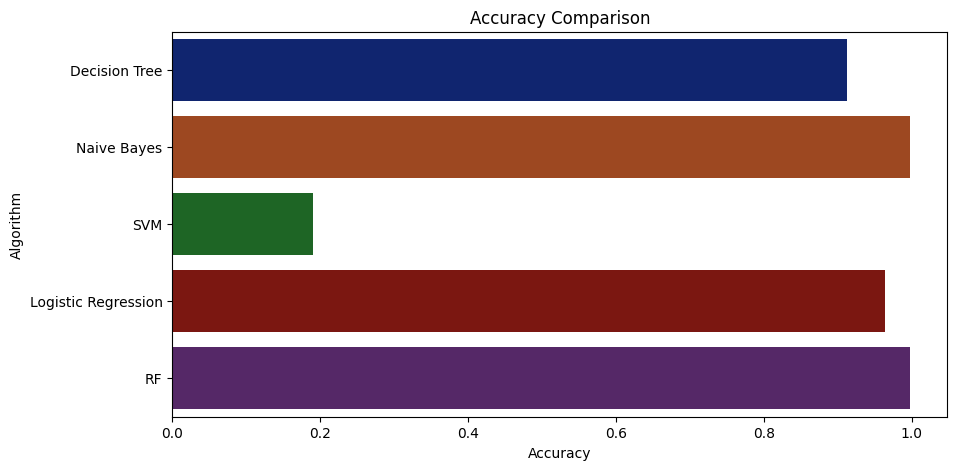

In [30]:
plt.figure(figsize=[10,5],dpi = 100)
plt.title('Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Algorithm')
sns.barplot(x = acc,y = model,palette='dark')

In [31]:
accuracy_models = dict(zip(model, acc))
for k, v in accuracy_models.items():
    print (k, '-->', v)

Decision Tree --> 0.912
Naive Bayes --> 0.998
SVM --> 0.19
Logistic Regression --> 0.964
RF --> 0.998


In [32]:
data = np.array([[30, 45, 25, 26.0, 45.0, 7.8, 450.0]])
prediction = DecisionTree.predict(data)
print(prediction)
prediction = NaiveBayes.predict(data)
print(prediction)
prediction = SVM.predict(data)
print(prediction)
prediction = LogReg.predict(data)
print(prediction)





['blueberry']
['pigeonpeas']
['pigeonpeas']
['rice']


In [33]:
test_coffee = np.array([[100, 20, 30, 25.0, 55.0, 6.8, 150.0]])

prediction = RF.predict(data)
print(prediction)


['pigeonpeas']


In [34]:
test_rice = np.array([[90, 42, 43, 20.8, 82.0, 6.5, 202.9]])


prediction = RF.predict(data)
print(prediction)

['pigeonpeas']


In [35]:
data = np.array([[83, 45, 60, 8, 70.3, 7.0, 150.9]])
prediction = RF.predict(data)
print(prediction)

['jute']
